## Hartmann

Qué hace el modelo Hartmann
El modelo de Hartmann lee cada línea de diálogo y le asigna una de 7 emociones:

anger — ira

fear — miedo

joy — alegría

sadness — tristeza

surprise — sorpresa

disgust — asco

neutral — neutro


Lo hace con una red neuronal entrenada sobre decenas de miles de ejemplos etiquetados por humanos. Para cada texto devuelve la emoción más probable y un score de confianza entre 0 y 1.

In [4]:
import pickle
import pandas as pd
from transformers import pipeline

# Cargar dataset
with open("Dataset_final.pkl", "rb") as f:
    df = pickle.load(f)

peliculas_excluidas = ['Talk to Her', 'Anatomy of a Fall']
df = df[~df['Title'].isin(peliculas_excluidas)].reset_index(drop=True)

print(f"Películas cargadas: {len(df)}")

# Cargar modelo de emociones
print("Cargando modelo Hartmann...")
emotion_classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=1
)
print("Modelo cargado correctamente.")

c:\Users\gleds\Dropbox\Gledson\Gledson\HACKABOSS\ProyectoCine\Proyecto_Cine_VS\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Películas cargadas: 75
Cargando modelo Hartmann...


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 15045.16it/s]


Modelo cargado correctamente.


In [5]:
# Probar el modelo con ejemplos
frases = [
    "I love you, you are the most beautiful thing I have ever seen",
    "I will kill you, you miserable bastard",
    "She died last night, I can't stop crying",
    "I'm not scared of you",
    "Oh great, another disaster"
]

print("=== TEST DEL MODELO ===\n")
for frase in frases:
    resultado = emotion_classifier(frase[:512])
    emocion = resultado[0][0]['label']
    score = resultado[0][0]['score']
    print(f"'{frase[:60]}...'")
    print(f"  → {emocion} ({score:.2f})\n")

=== TEST DEL MODELO ===

'I love you, you are the most beautiful thing I have ever see...'
  → joy (0.95)

'I will kill you, you miserable bastard...'
  → anger (0.78)

'She died last night, I can't stop crying...'
  → sadness (0.95)

'I'm not scared of you...'
  → fear (0.97)

'Oh great, another disaster...'
  → surprise (0.64)



In [6]:
# Función para analizar emoción de un texto
def analizar_emocion(texto):
    try:
        resultado = emotion_classifier(texto[:512], truncation=True)
        return resultado[0][0]['label']
    except:
        return None

# Calcular emoción por personaje
resultados = []

for _, pelicula in df.iterrows():
    script = pelicula['Script_Dict']
    generos = pelicula['Characters_Genders']

    for personaje, texto in script.items():
        genero = generos.get(personaje, 'unknown')
        if genero == 'unknown':
            continue
        emocion = analizar_emocion(texto)
        if emocion is None:
            continue
        resultados.append({
            'titulo': pelicula['Title'],
            'award': pelicula['Award'],
            'oscar_year': pelicula['Oscar_Year'],
            'personaje': personaje,
            'genero': genero,
            'emocion': emocion
        })

print(f"Personajes analizados: {len(resultados)}")
print(f"Ejemplo: {resultados[0]}")

Personajes analizados: 3008
Ejemplo: {'titulo': 'The Lord of the Rings: The Return of the King', 'award': 'Best Picture', 'oscar_year': 2004, 'personaje': 'ARAGORN', 'genero': 'male', 'emocion': 'fear'}


Aragorn con fear tiene sentido — sus diálogos incluyen muchas referencias a la batalla, la muerte y la responsabilidad, que el modelo interpreta como miedo.

In [7]:
import pandas as pd

# Convertir a DataFrame
df_emociones = pd.DataFrame(resultados)

# Distribución de emociones por género
resumen = df_emociones.groupby(['genero', 'emocion']).size().unstack(fill_value=0)
resumen_pct = resumen.div(resumen.sum(axis=1), axis=0).round(3) * 100

print("Distribución de emociones por género (%):")
print(resumen_pct.to_string())

Distribución de emociones por género (%):
emocion  anger  disgust  fear  joy  neutral  sadness  surprise
genero                                                        
female    16.5     13.1   4.5  7.9     34.5      5.7      17.7
male      21.8     11.3   5.1  6.7     36.4      5.5      13.2


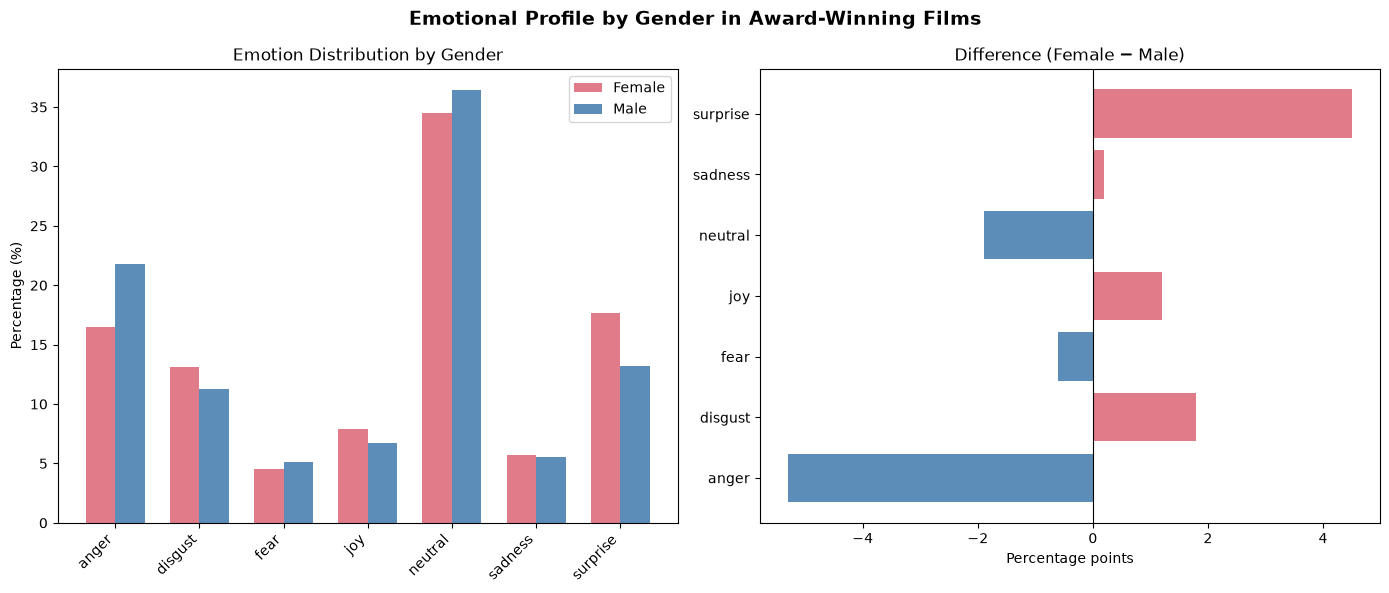

Gráfico guardado como hartmann_emociones.png


In [10]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Emotional Profile by Gender in Award-Winning Films", fontsize=14, fontweight='bold')

emociones = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']
female_vals = [resumen_pct.loc['female', e] for e in emociones]
male_vals = [resumen_pct.loc['male', e] for e in emociones]

x = np.arange(len(emociones))
width = 0.35

# Gráfico 1 — Barras agrupadas
axes[0].bar(x - width/2, female_vals, width, label='Female', color='#E07B8A')
axes[0].bar(x + width/2, male_vals, width, label='Male', color='#5B8DB8')
axes[0].set_title("Emotion Distribution by Gender")
axes[0].set_xticks(x)
axes[0].set_xticklabels(emociones, rotation=45, ha='right')
axes[0].set_ylabel("Percentage (%)")
axes[0].legend()

# Gráfico 2 — Diferencia female - male
diferencia = [f - m for f, m in zip(female_vals, male_vals)]
colores = ['#E07B8A' if d > 0 else '#5B8DB8' for d in diferencia]
axes[1].barh(emociones, diferencia, color=colores)
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title("Difference (Female − Male)")
axes[1].set_xlabel("Percentage points")

plt.tight_layout()
plt.savefig("hartmann_emociones.png", dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico guardado como hartmann_emociones.png")

NameError: name 'resumen_award_pct' is not defined

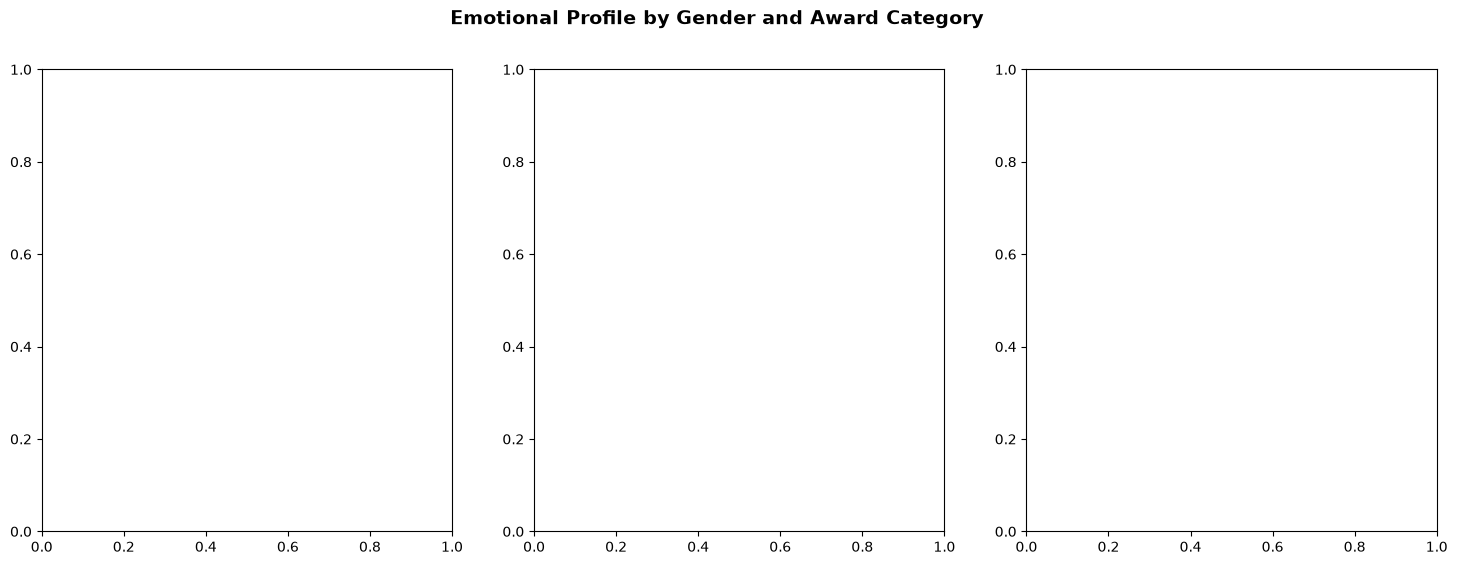

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Emotional Profile by Gender and Award Category", fontsize=14, fontweight='bold')

awards = ['Best Picture', 'Original Screenplay', 'Adapted Screenplay']
emociones = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']
x = np.arange(len(emociones))
width = 0.35

for i, award in enumerate(awards):
    female_vals = [resumen_award_pct.loc[(award, 'female'), e] for e in emociones]
    male_vals = [resumen_award_pct.loc[(award, 'male'), e] for e in emociones]

    axes[i].bar(x - width/2, female_vals, width, label='Female', color='#E07B8A')
    axes[i].bar(x + width/2, male_vals, width, label='Male', color='#5B8DB8')

    for j, v in enumerate(female_vals):
        axes[i].text(j - width/2, v + 0.3, f'{v:.1f}', ha='center', fontsize=7, color='#E07B8A')
    for j, v in enumerate(male_vals):
        axes[i].text(j + width/2, v + 0.3, f'{v:.1f}', ha='center', fontsize=7, color='#5B8DB8')

    axes[i].set_title(award)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(emociones, rotation=45, ha='right')
    axes[i].set_ylabel("Percentage (%)")
    axes[i].legend()

plt.tight_layout()
plt.savefig("hartmann_emociones_award.png", dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico guardado como hartmann_emociones_award.png")

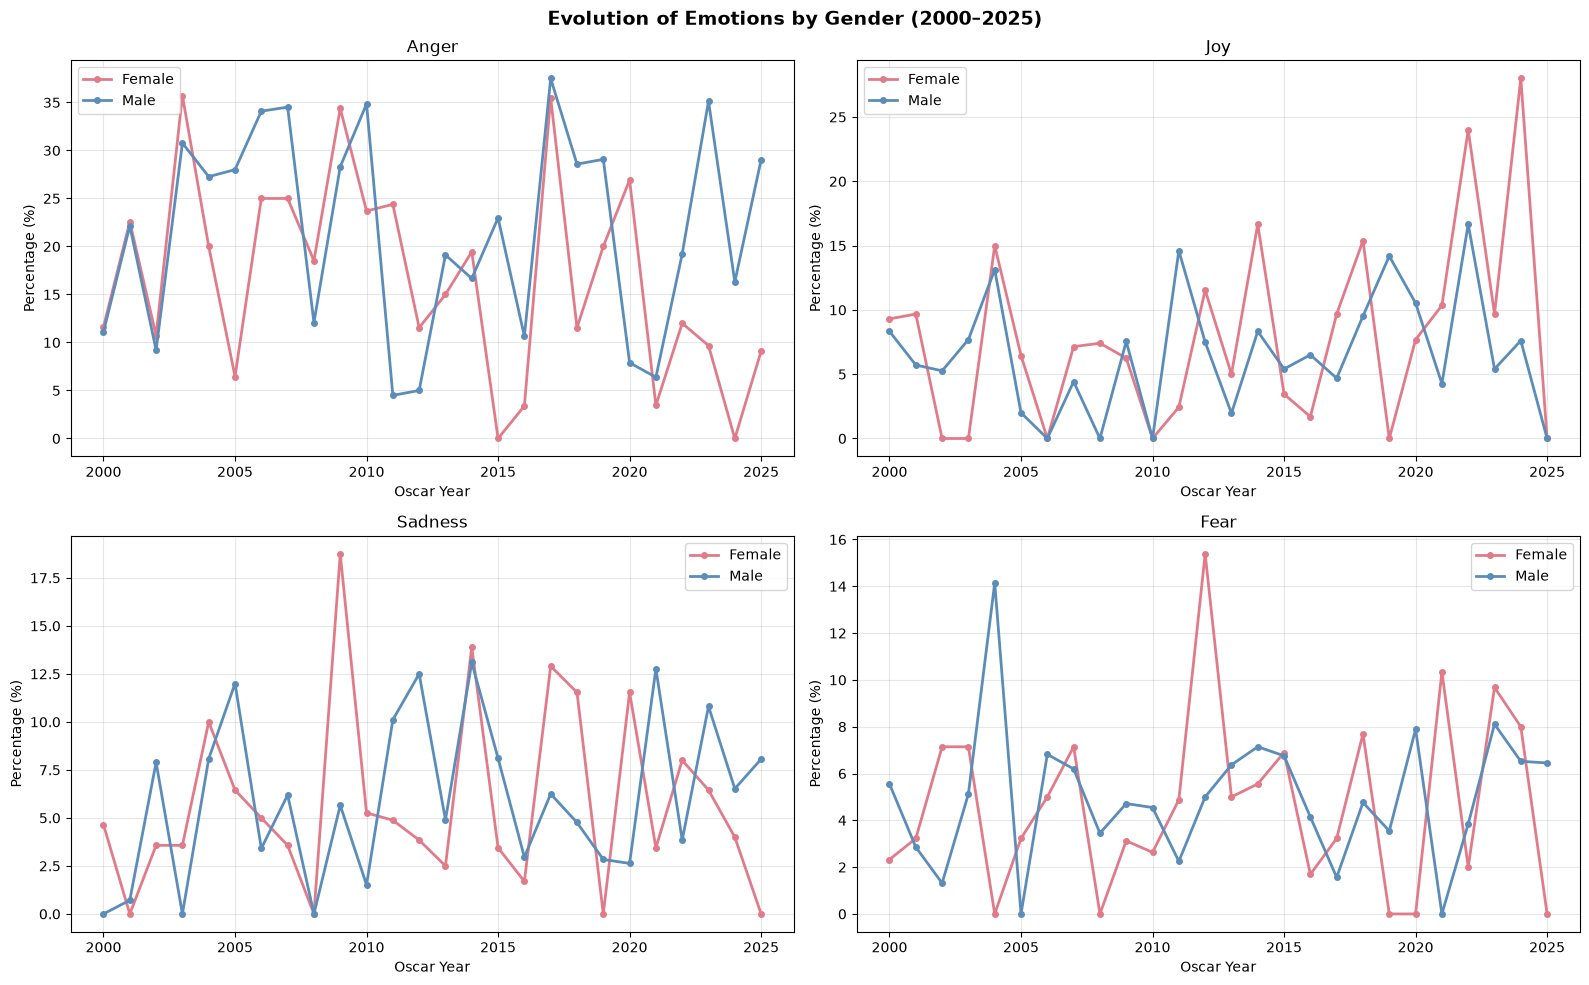

Gráfico guardado como hartmann_evolucion_temporal.png


In [12]:
# Gráfico 1 — Evolución temporal de emociones
emociones_temporal = df_emociones.groupby(['oscar_year', 'genero', 'emocion']).size().unstack(fill_value=0)
emociones_temporal_pct = emociones_temporal.div(emociones_temporal.sum(axis=1), axis=0) * 100

emociones_plot = ['anger', 'joy', 'sadness', 'fear']
colores_emocion = {'anger': '#C0392B', 'joy': '#F1C40F', 'sadness': '#2980B9', 'fear': '#8E44AD'}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Evolution of Emotions by Gender (2000–2025)", fontsize=14, fontweight='bold')

for idx, emocion in enumerate(emociones_plot):
    ax = axes[idx // 2][idx % 2]
    for genero, color, label in [('female', '#E07B8A', 'Female'), ('male', '#5B8DB8', 'Male')]:
        datos = emociones_temporal_pct.xs(genero, level='genero')[emocion].reset_index()
        ax.plot(datos['oscar_year'], datos[emocion], color=color, label=label, linewidth=2, marker='o', markersize=4)
    ax.set_title(emocion.capitalize())
    ax.set_xlabel("Oscar Year")
    ax.set_ylabel("Percentage (%)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("hartmann_evolucion_temporal.png", dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico guardado como hartmann_evolucion_temporal.png")

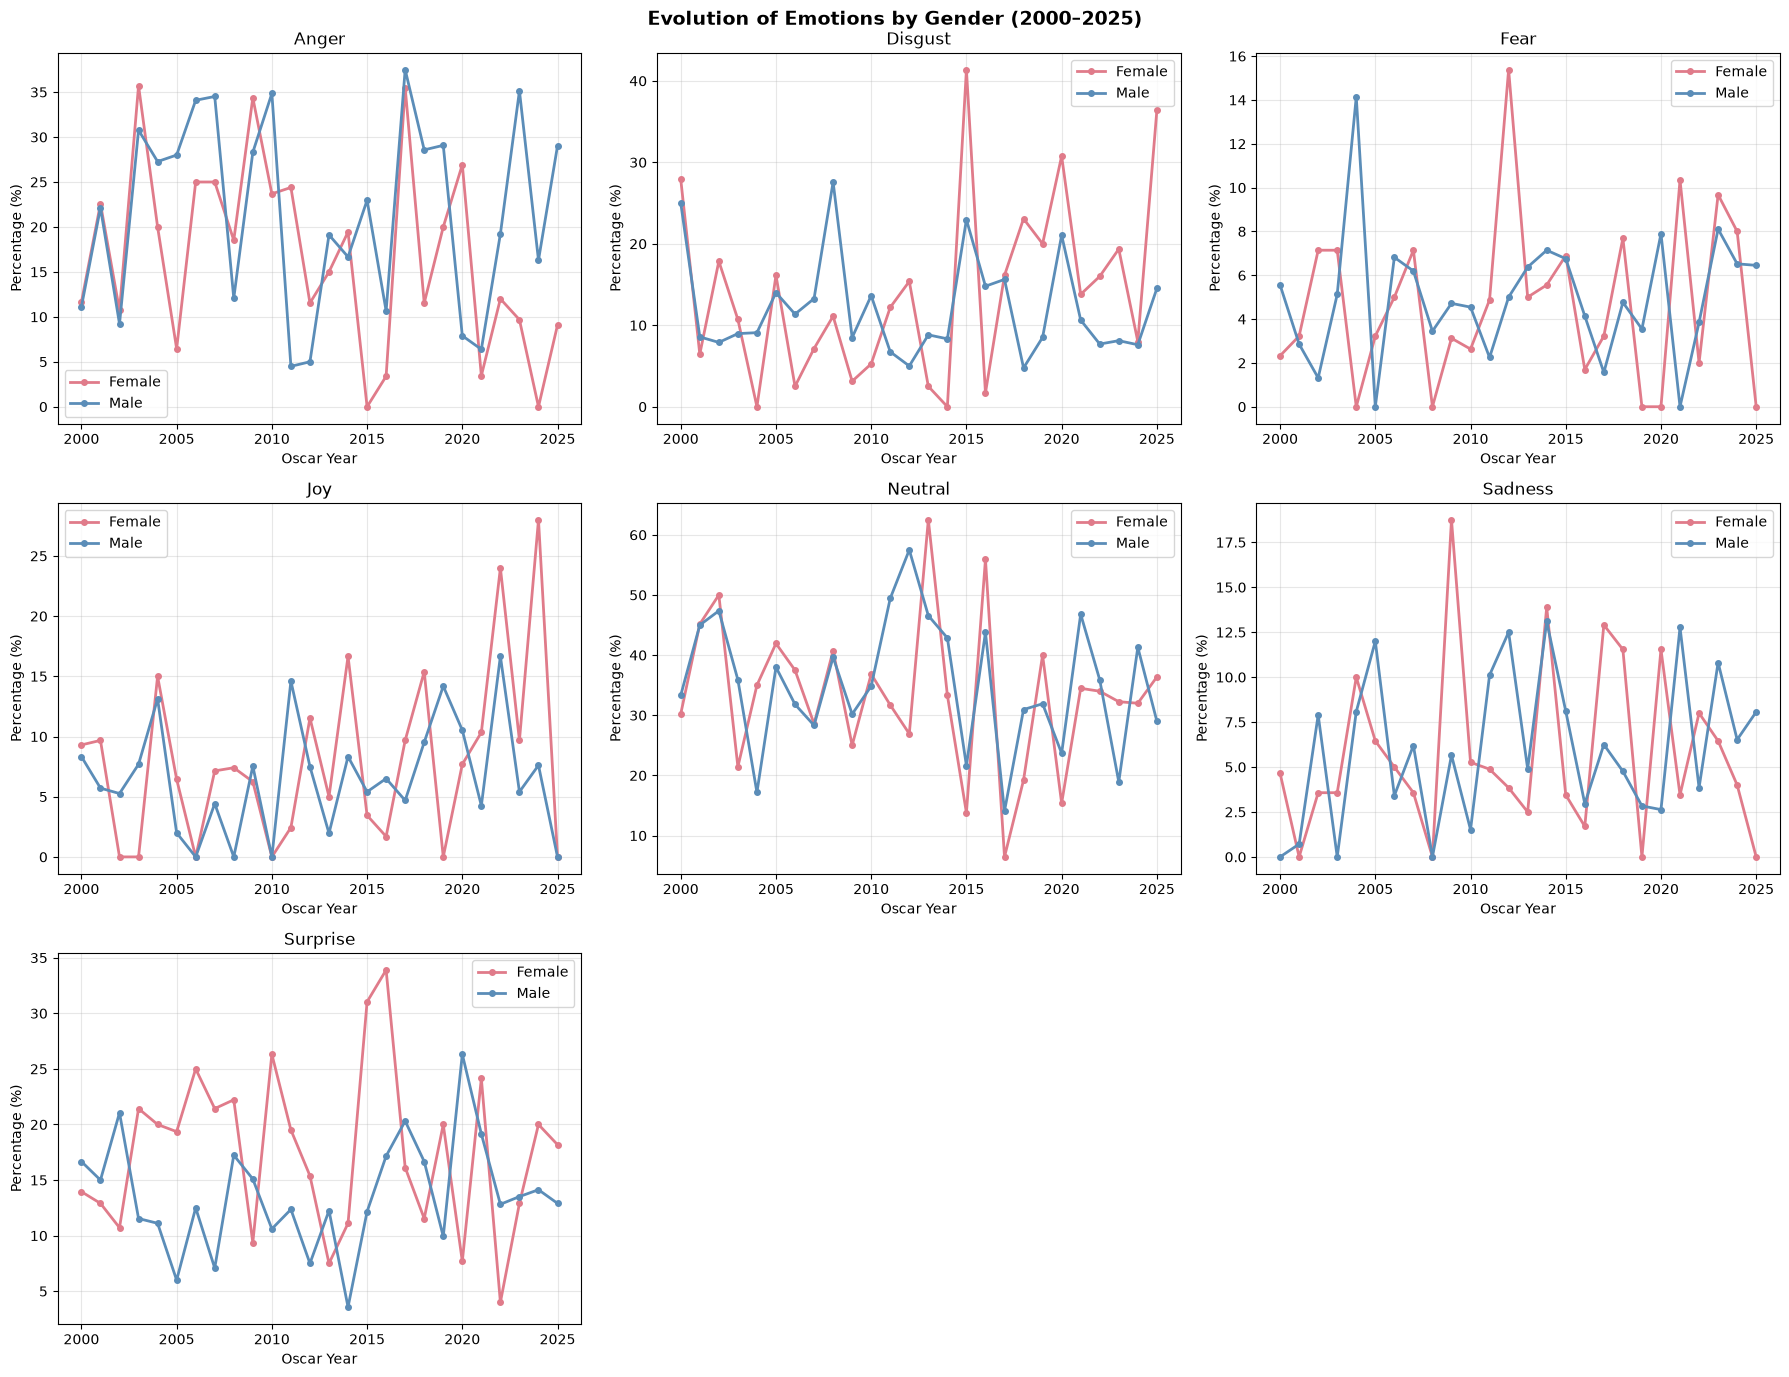

Gráfico guardado como hartmann_evolucion_7emociones.png


In [13]:
# Gráfico 1 ampliado — Evolución temporal de las 7 emociones
emociones_todas = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle("Evolution of Emotions by Gender (2000–2025)", fontsize=14, fontweight='bold')

# Aplanar axes para iterar fácilmente
axes_flat = axes.flatten()

for idx, emocion in enumerate(emociones_todas):
    ax = axes_flat[idx]
    for genero, color, label in [('female', '#E07B8A', 'Female'), ('male', '#5B8DB8', 'Male')]:
        datos = emociones_temporal_pct.xs(genero, level='genero')[emocion].reset_index()
        ax.plot(datos['oscar_year'], datos[emocion], color=color, label=label, linewidth=2, marker='o', markersize=4)
    ax.set_title(emocion.capitalize())
    ax.set_xlabel("Oscar Year")
    ax.set_ylabel("Percentage (%)")
    ax.legend()
    ax.grid(True, alpha=0.3)

# Ocultar el subplot vacío (posición 8)
axes_flat[7].axis('off')
axes_flat[8].axis('off')

plt.tight_layout()
plt.savefig("hartmann_evolucion_7emociones.png", dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico guardado como hartmann_evolucion_7emociones.png")

In [14]:
# Tabla por año, género y categoría de premio
tabla = df_emociones.groupby(['oscar_year', 'award', 'genero', 'emocion']).size().unstack(fill_value=0)
tabla_pct = tabla.div(tabla.sum(axis=1), axis=0).round(3) * 100

# Guardar como CSV para verla completa
tabla_pct.to_csv("hartmann_tabla_completa.csv")
print("Tabla guardada como hartmann_tabla_completa.csv")

# Preview de los primeros registros
print("\nPrimeras filas:")
print(tabla_pct.head(10).to_string())

Tabla guardada como hartmann_tabla_completa.csv

Primeras filas:
emocion                                anger  disgust  fear   joy  neutral  sadness  surprise
oscar_year award               genero                                                        
2000       Adapted Screenplay  female   23.8     19.0   4.8   9.5     23.8      0.0      19.0
                               male     11.1     27.8  11.1   5.6     22.2      0.0      22.2
           Best Picture        female    0.0     36.4   0.0   9.1     36.4      9.1       9.1
                               male     11.1     22.2   0.0  11.1     44.4      0.0      11.1
           Original Screenplay female    0.0     36.4   0.0   9.1     36.4      9.1       9.1
                               male     11.1     22.2   0.0  11.1     44.4      0.0      11.1
2001       Adapted Screenplay  female   25.0      6.2   6.2   6.2     50.0      0.0       6.2
                               male     21.6     12.2   4.1   2.7     48.6      1.4      

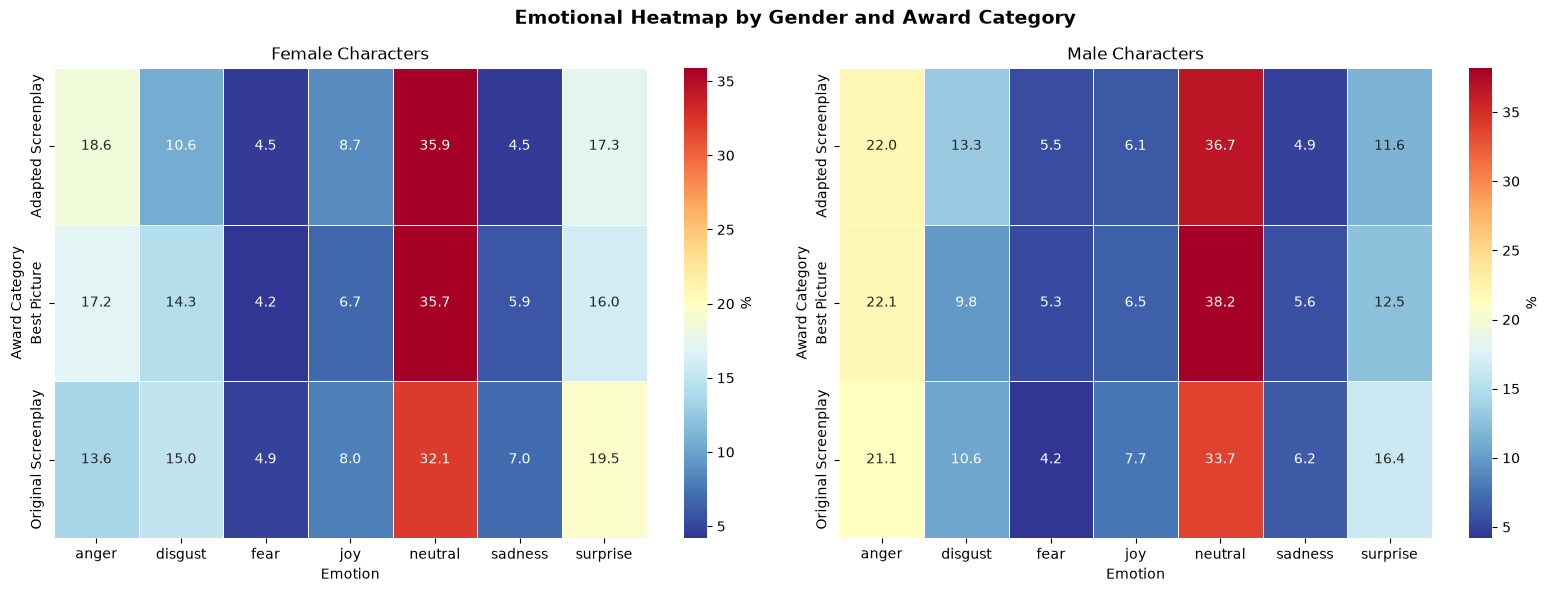

Gráfico guardado como hartmann_heatmap.png


In [15]:
import seaborn as sns

# Preparar datos para heatmap
heatmap_data = df_emociones.groupby(['award', 'genero', 'emocion']).size().unstack(fill_value=0)
heatmap_pct = heatmap_data.div(heatmap_data.sum(axis=1), axis=0).round(3) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Emotional Heatmap by Gender and Award Category", fontsize=14, fontweight='bold')

for idx, genero in enumerate(['female', 'male']):
    datos = heatmap_pct.xs(genero, level='genero')
    sns.heatmap(
        datos,
        ax=axes[idx],
        cmap='RdYlBu_r',
        annot=True,
        fmt='.1f',
        linewidths=0.5,
        cbar_kws={'label': '%'}
    )
    axes[idx].set_title(f"{'Female' if genero == 'female' else 'Male'} Characters")
    axes[idx].set_xlabel("Emotion")
    axes[idx].set_ylabel("Award Category")

plt.tight_layout()
plt.savefig("hartmann_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico guardado como hartmann_heatmap.png")

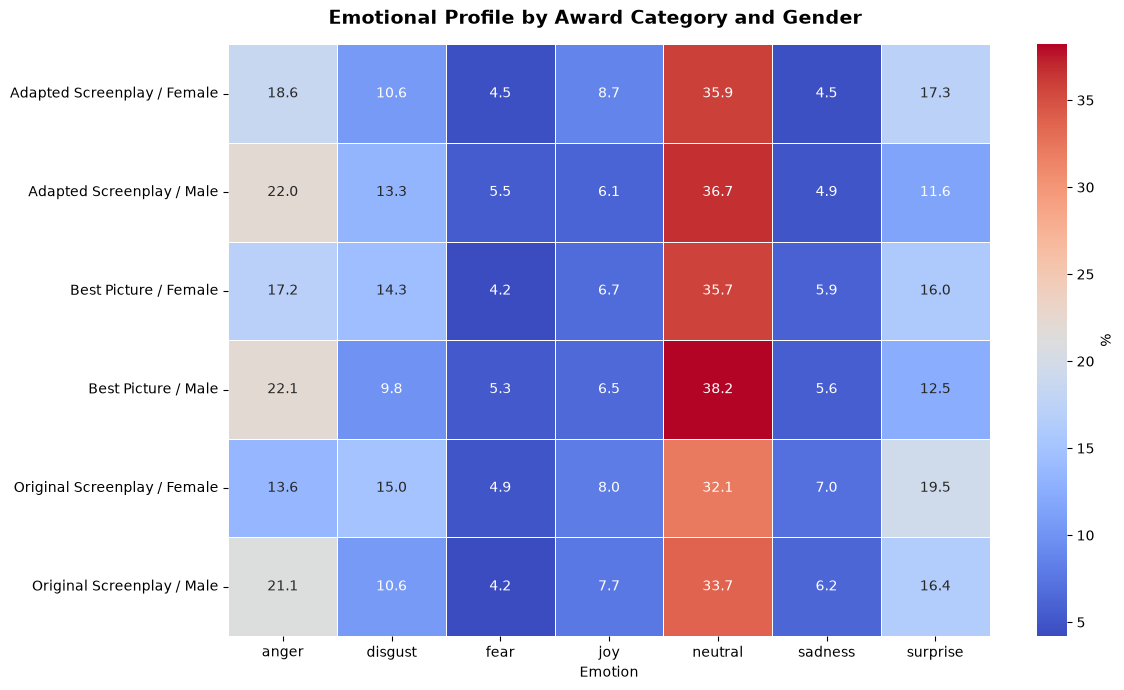

Gráfico guardado como hartmann_heatmap_combinado.png


In [16]:
# Heatmap con award × género en las filas
heatmap_combinado = df_emociones.groupby(['award', 'genero', 'emocion']).size().unstack(fill_value=0)
heatmap_combinado_pct = heatmap_combinado.div(heatmap_combinado.sum(axis=1), axis=0).round(3) * 100

# Renombrar índice para que sea más legible
heatmap_combinado_pct.index = [f"{award} / {genero.capitalize()}" 
                                for award, genero in heatmap_combinado_pct.index]

fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle("Emotional Profile by Award Category and Gender", fontsize=14, fontweight='bold')

sns.heatmap(
    heatmap_combinado_pct,
    ax=ax,
    cmap='coolwarm',
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    cbar_kws={'label': '%'}
)
ax.set_xlabel("Emotion")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig("hartmann_heatmap_combinado.png", dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico guardado como hartmann_heatmap_combinado.png")

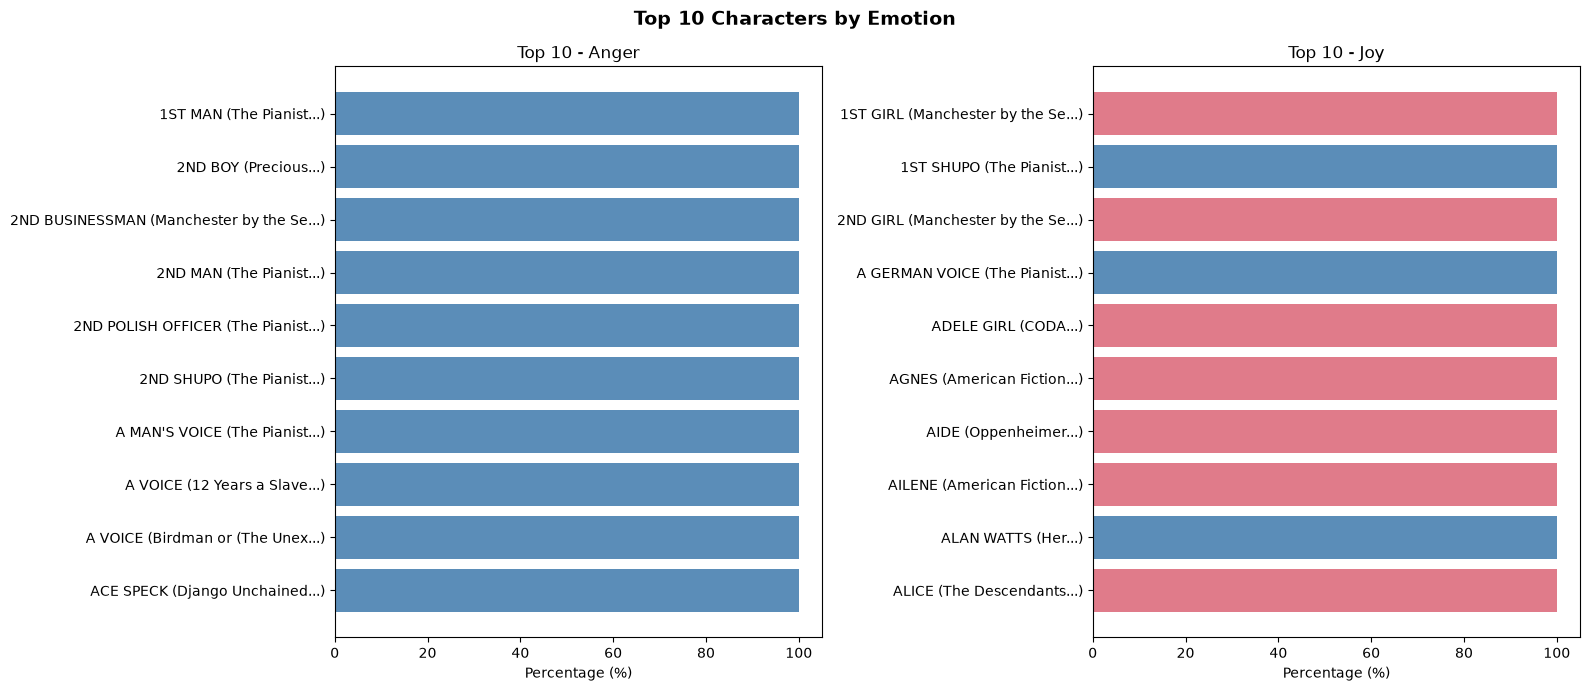

Gráfico guardado como hartmann_top10.png


In [17]:
# Top 10 personajes con mayor anger y mayor joy
df_emociones_conteo = df_emociones.groupby(['personaje', 'titulo', 'genero', 'emocion']).size().reset_index(name='count')
df_emociones_total = df_emociones.groupby(['personaje', 'titulo', 'genero']).size().reset_index(name='total')
df_emociones_merge = df_emociones_conteo.merge(df_emociones_total, on=['personaje', 'titulo', 'genero'])
df_emociones_merge['pct'] = (df_emociones_merge['count'] / df_emociones_merge['total'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Top 10 Characters by Emotion", fontsize=14, fontweight='bold')

for idx, emocion in enumerate(['anger', 'joy']):
    datos = df_emociones_merge[df_emociones_merge['emocion'] == emocion].nlargest(10, 'pct')
    etiquetas = [f"{row['personaje']} ({row['titulo'][:20]}...)" for _, row in datos.iterrows()]
    colores = ['#E07B8A' if g == 'female' else '#5B8DB8' for g in datos['genero']]
    axes[idx].barh(etiquetas, datos['pct'], color=colores)
    axes[idx].set_title(f"Top 10 - {emocion.capitalize()}")
    axes[idx].set_xlabel("Percentage (%)")
    axes[idx].invert_yaxis()

plt.tight_layout()
plt.savefig("hartmann_top10.png", dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico guardado como hartmann_top10.png")

In [18]:
# Cargar resultados de agencia que ya tienen el conteo de palabras
df_agencia_filtrado = pd.read_csv("resultados_agencia_filtrado.csv")

# Obtener lista de personajes con más de 50 palabras
personajes_50 = df_agencia_filtrado[['titulo', 'personaje']].drop_duplicates()

# Filtrar df_emociones
df_emociones_filtrado = df_emociones.merge(
    personajes_50,
    left_on=['titulo', 'personaje'],
    right_on=['titulo', 'personaje']
)

print(f"Personajes antes del filtro: {len(df_emociones['personaje'].unique())}")
print(f"Personajes después del filtro (mín. 50 palabras): {len(df_emociones_filtrado['personaje'].unique())}")

Personajes antes del filtro: 1895
Personajes después del filtro (mín. 50 palabras): 943


NameError: name 'df_emociones_merge2' is not defined

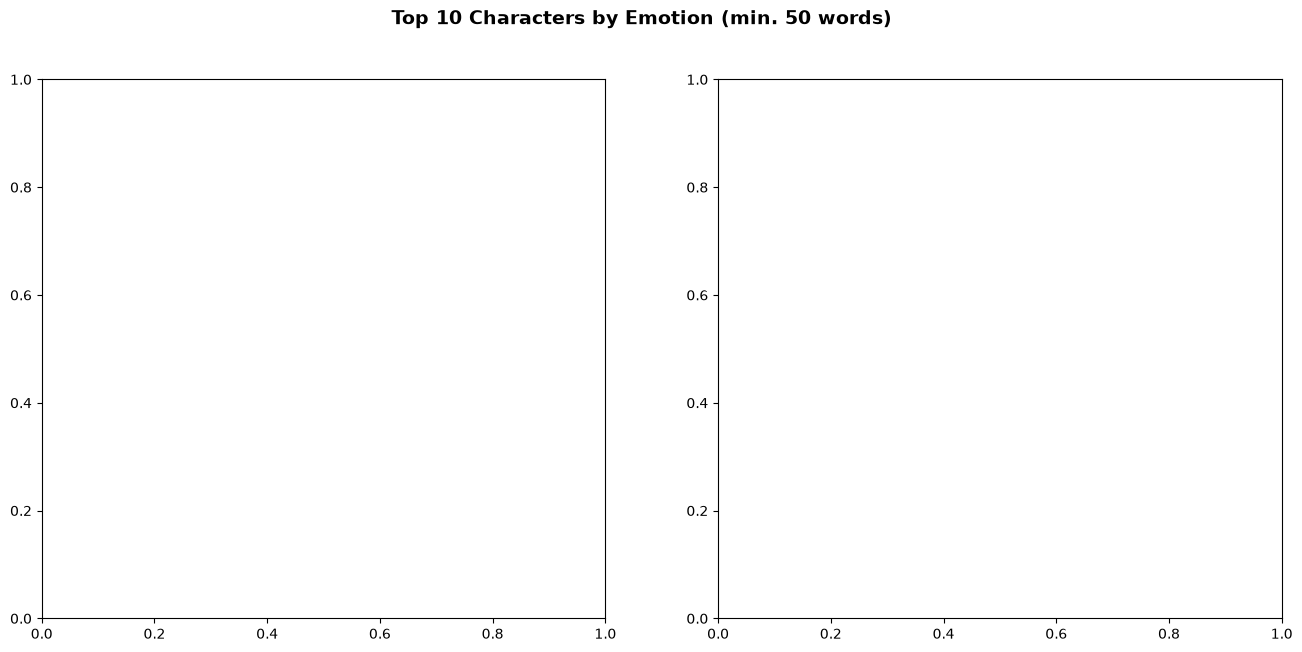

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Top 10 Characters by Emotion (min. 50 words)", fontsize=14, fontweight='bold')

for idx, emocion in enumerate(['anger', 'joy']):
    datos = df_emociones_merge2[df_emociones_merge2['emocion'] == emocion].nlargest(10, 'pct')
    etiquetas = [f"{row['personaje']} ({row['titulo'][:20]}...)" for _, row in datos.iterrows()]
    colores = ['#E07B8A' if g == 'female' else '#5B8DB8' for g in datos['genero']]
    bars = axes[idx].barh(etiquetas, datos['pct'], color=colores)
    axes[idx].set_title(f"Top 10 - {emocion.capitalize()}")
    axes[idx].set_xlabel("Percentage (%)")
    axes[idx].invert_yaxis()

    # Números en las barras
    for bar, val in zip(bars, datos['pct']):
        axes[idx].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                      f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig("hartmann_top10_filtrado.png", dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico guardado como hartmann_top10_filtrado.png")

El problema de fondo
Estamos clasificando a nivel de personaje, no a nivel de frase. Un personaje con 50 palabras recibe exactamente la misma clasificación que uno con 5000 palabras — una sola emoción.
Para un análisis más preciso y publicable habría que dividir los diálogos en frases individuales y clasificar cada una. Así ARAGORN podría tener 40% anger, 30% fear, 20% neutral en lugar de un único valor.

¿Lo hacemos así?
Sería el análisis correcto para el artículo. El código cambiaría para dividir cada diálogo en frases con spaCy antes de pasarlo por Hartmann. Tarda más pero los resultados serían mucho más matizados y defendibles.

In [20]:
import spacy
nlp = spacy.load("en_core_web_lg")

# Función que divide el texto en frases y clasifica cada una
def analizar_emociones_por_frase(texto):
    doc = nlp(texto)
    frases = [sent.text.strip() for sent in doc.sents if len(sent.text.strip()) > 10]
    if not frases:
        return None
    resultados = []
    for frase in frases:
        try:
            resultado = emotion_classifier(frase[:512], truncation=True)
            emocion = resultado[0][0]['label']
            resultados.append(emocion)
        except:
            continue
    return resultados

# Aplicar a todos los personajes con más de 50 palabras
print("Analizando emociones por frase...")
resultados_frases = []

for _, pelicula in df.iterrows():
    script = pelicula['Script_Dict']
    generos = pelicula['Characters_Genders']

    for personaje, texto in script.items():
        genero = generos.get(personaje, 'unknown')
        if genero == 'unknown':
            continue
        palabras = len(texto.split())
        if palabras < 50:
            continue
        emociones = analizar_emociones_por_frase(texto)
        if not emociones:
            continue
        for emocion in emociones:
            resultados_frases.append({
                'titulo': pelicula['Title'],
                'award': pelicula['Award'],
                'oscar_year': pelicula['Oscar_Year'],
                'personaje': personaje,
                'genero': genero,
                'emocion': emocion
            })

print(f"Frases analizadas: {len(resultados_frases)}")

Analizando emociones por frase...
Frases analizadas: 91236


In [21]:
# Convertir a DataFrame
df_frases = pd.DataFrame(resultados_frases)

# Distribución de emociones por género
resumen_frases = df_frases.groupby(['genero', 'emocion']).size().unstack(fill_value=0)
resumen_frases_pct = resumen_frases.div(resumen_frases.sum(axis=1), axis=0).round(3) * 100

print("Distribución de emociones por género (%) — análisis por frase:")
print(resumen_frases_pct.to_string())

Distribución de emociones por género (%) — análisis por frase:
emocion  anger  disgust  fear  joy  neutral  sadness  surprise
genero                                                        
female    11.6      8.6   3.3  7.6     48.7      6.0      14.2
male      11.8      8.8   3.2  5.9     52.9      4.9      12.5


Guardado correctamente.


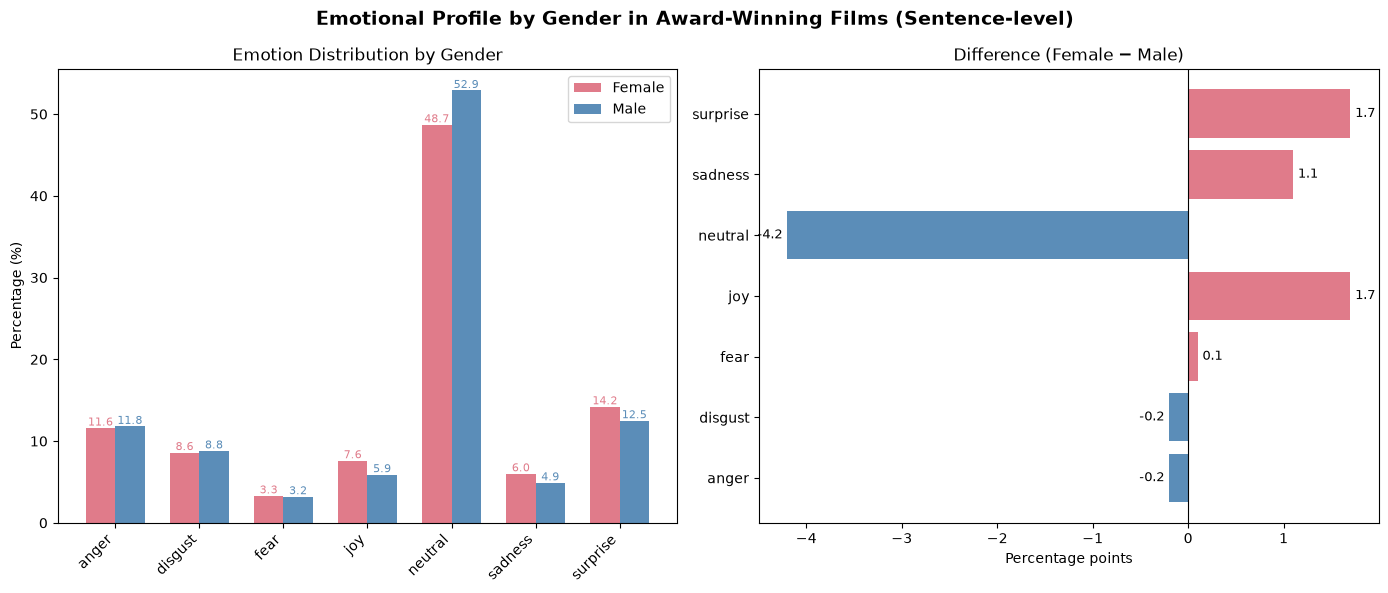

Gráfico guardado como hartmann_emociones_frases.png


In [22]:
# Guardar resultados por frase
df_frases.to_pickle("resultados_hartmann_frases.pkl")
print("Guardado correctamente.")

# Rehacer gráfico principal con datos por frase
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Emotional Profile by Gender in Award-Winning Films (Sentence-level)", fontsize=14, fontweight='bold')

emociones = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']
female_vals = [resumen_frases_pct.loc['female', e] for e in emociones]
male_vals = [resumen_frases_pct.loc['male', e] for e in emociones]

x = np.arange(len(emociones))
width = 0.35

# Gráfico 1 — Barras agrupadas
bars_f = axes[0].bar(x - width/2, female_vals, width, label='Female', color='#E07B8A')
bars_m = axes[0].bar(x + width/2, male_vals, width, label='Male', color='#5B8DB8')
axes[0].set_title("Emotion Distribution by Gender")
axes[0].set_xticks(x)
axes[0].set_xticklabels(emociones, rotation=45, ha='right')
axes[0].set_ylabel("Percentage (%)")
axes[0].legend()
for bar, val in zip(bars_f, female_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}', ha='center', fontsize=8, color='#E07B8A')
for bar, val in zip(bars_m, male_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}', ha='center', fontsize=8, color='#5B8DB8')

# Gráfico 2 — Diferencia female - male
diferencia = [f - m for f, m in zip(female_vals, male_vals)]
colores = ['#E07B8A' if d > 0 else '#5B8DB8' for d in diferencia]
bars_d = axes[1].barh(emociones, diferencia, color=colores)
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title("Difference (Female − Male)")
axes[1].set_xlabel("Percentage points")
for bar, val in zip(bars_d, diferencia):
    axes[1].text(val + 0.05 if val >= 0 else val - 0.05, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig("hartmann_emociones_frases.png", dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico guardado como hartmann_emociones_frases.png")

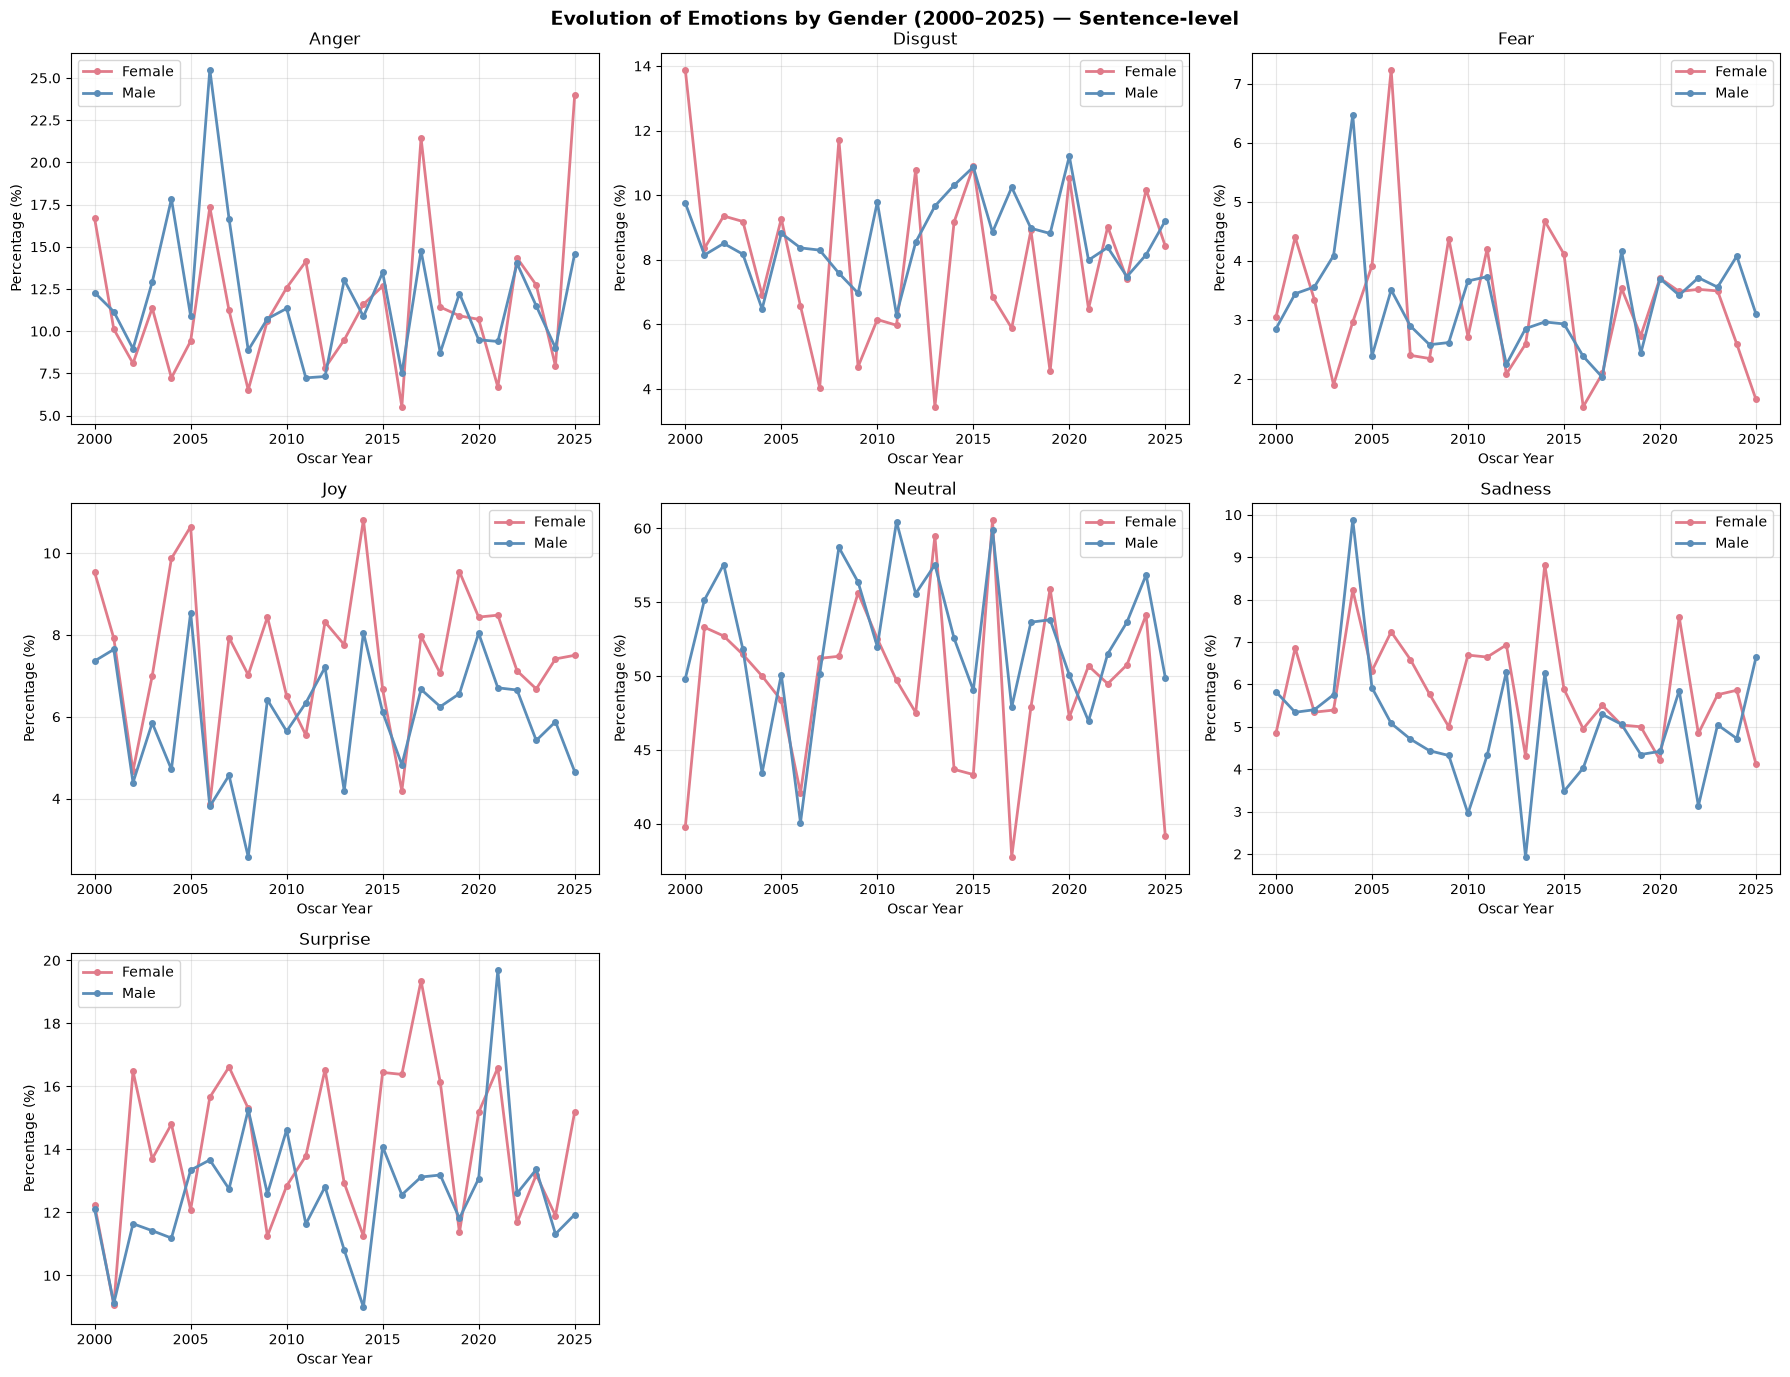

Gráfico guardado como hartmann_evolucion_frases.png


In [23]:
# Evolución temporal con datos por frase
emociones_temporal2 = df_frases.groupby(['oscar_year', 'genero', 'emocion']).size().unstack(fill_value=0)
emociones_temporal2_pct = emociones_temporal2.div(emociones_temporal2.sum(axis=1), axis=0) * 100

emociones_todas = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle("Evolution of Emotions by Gender (2000–2025) — Sentence-level", fontsize=14, fontweight='bold')

axes_flat = axes.flatten()

for idx, emocion in enumerate(emociones_todas):
    ax = axes_flat[idx]
    for genero, color, label in [('female', '#E07B8A', 'Female'), ('male', '#5B8DB8', 'Male')]:
        datos = emociones_temporal2_pct.xs(genero, level='genero')[emocion].reset_index()
        ax.plot(datos['oscar_year'], datos[emocion], color=color, label=label, linewidth=2, marker='o', markersize=4)
    ax.set_title(emocion.capitalize())
    ax.set_xlabel("Oscar Year")
    ax.set_ylabel("Percentage (%)")
    ax.legend()
    ax.grid(True, alpha=0.3)

axes_flat[7].axis('off')
axes_flat[8].axis('off')

plt.tight_layout()
plt.savefig("hartmann_evolucion_frases.png", dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico guardado como hartmann_evolucion_frases.png")

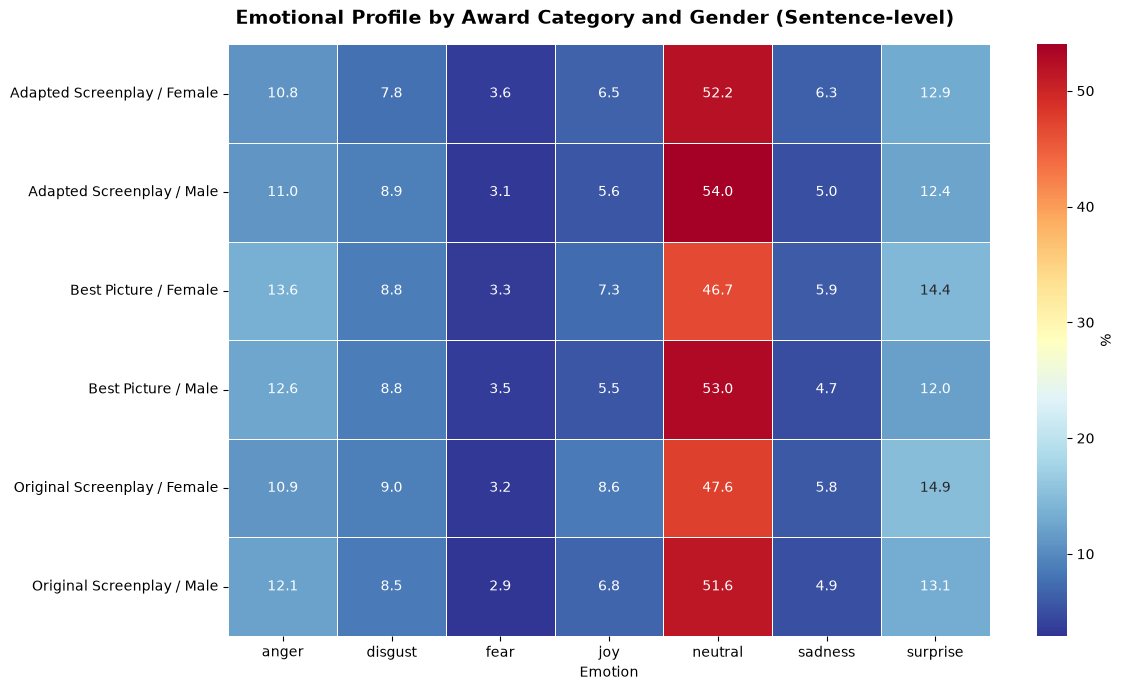

Gráfico guardado como hartmann_heatmap_frases.png


In [24]:
# Heatmap con datos por frase
heatmap_combinado2 = df_frases.groupby(['award', 'genero', 'emocion']).size().unstack(fill_value=0)
heatmap_combinado2_pct = heatmap_combinado2.div(heatmap_combinado2.sum(axis=1), axis=0).round(3) * 100

heatmap_combinado2_pct.index = [f"{award} / {genero.capitalize()}"
                                 for award, genero in heatmap_combinado2_pct.index]

fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle("Emotional Profile by Award Category and Gender (Sentence-level)", fontsize=14, fontweight='bold')

sns.heatmap(
    heatmap_combinado2_pct,
    ax=ax,
    cmap='RdYlBu_r',
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    cbar_kws={'label': '%'}
)
ax.set_xlabel("Emotion")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig("hartmann_heatmap_frases.png", dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico guardado como hartmann_heatmap_frases.png")

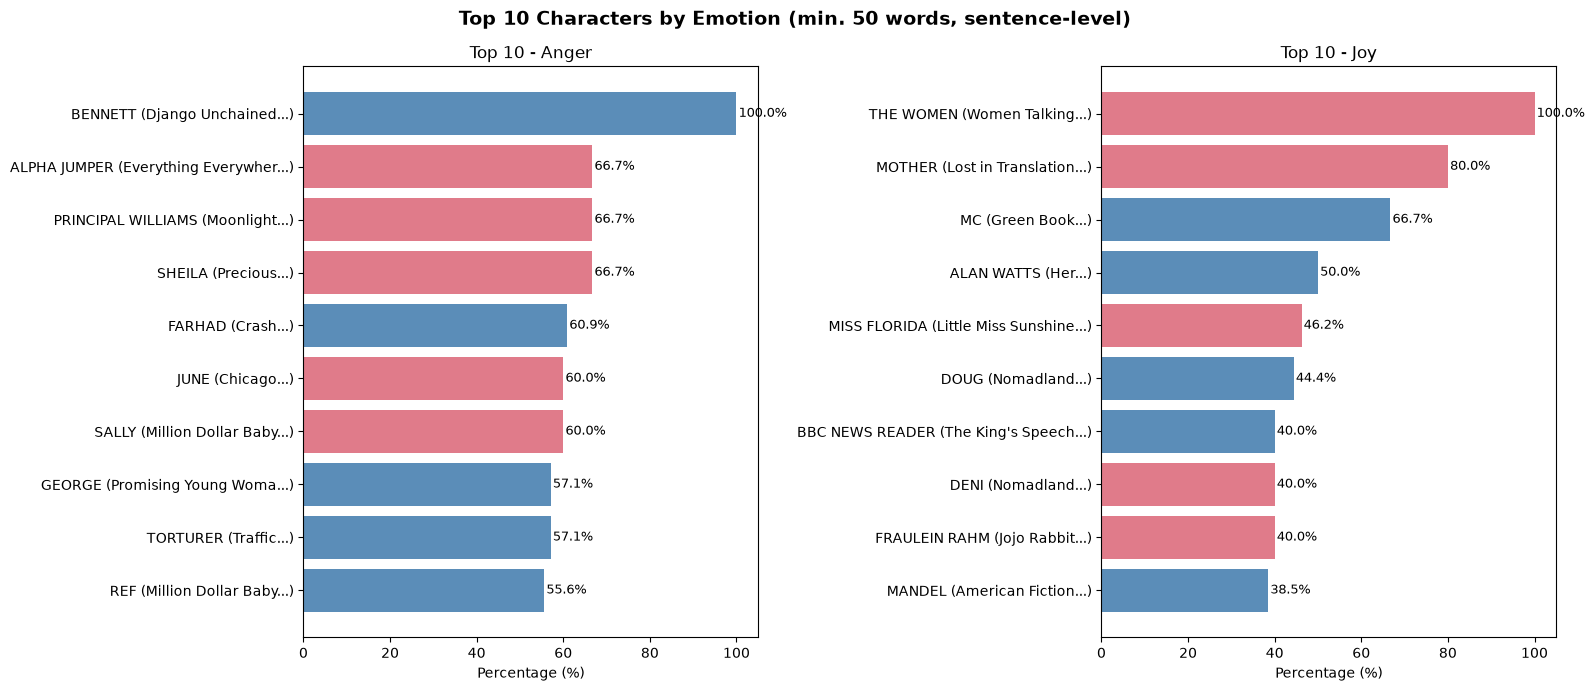

Gráfico guardado como hartmann_top10_frases.png


In [25]:
# Top 10 por frase
df_frases_conteo = df_frases.groupby(['personaje', 'titulo', 'genero', 'emocion']).size().reset_index(name='count')
df_frases_total = df_frases.groupby(['personaje', 'titulo', 'genero']).size().reset_index(name='total')
df_frases_merge = df_frases_conteo.merge(df_frases_total, on=['personaje', 'titulo', 'genero'])
df_frases_merge['pct'] = (df_frases_merge['count'] / df_frases_merge['total'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Top 10 Characters by Emotion (min. 50 words, sentence-level)", fontsize=14, fontweight='bold')

for idx, emocion in enumerate(['anger', 'joy']):
    datos = df_frases_merge[df_frases_merge['emocion'] == emocion].nlargest(10, 'pct')
    etiquetas = [f"{row['personaje']} ({row['titulo'][:20]}...)" for _, row in datos.iterrows()]
    colores = ['#E07B8A' if g == 'female' else '#5B8DB8' for g in datos['genero']]
    bars = axes[idx].barh(etiquetas, datos['pct'], color=colores)
    axes[idx].set_title(f"Top 10 - {emocion.capitalize()}")
    axes[idx].set_xlabel("Percentage (%)")
    axes[idx].invert_yaxis()
    for bar, val in zip(bars, datos['pct']):
        axes[idx].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                      f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig("hartmann_top10_frases.png", dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico guardado como hartmann_top10_frases.png")

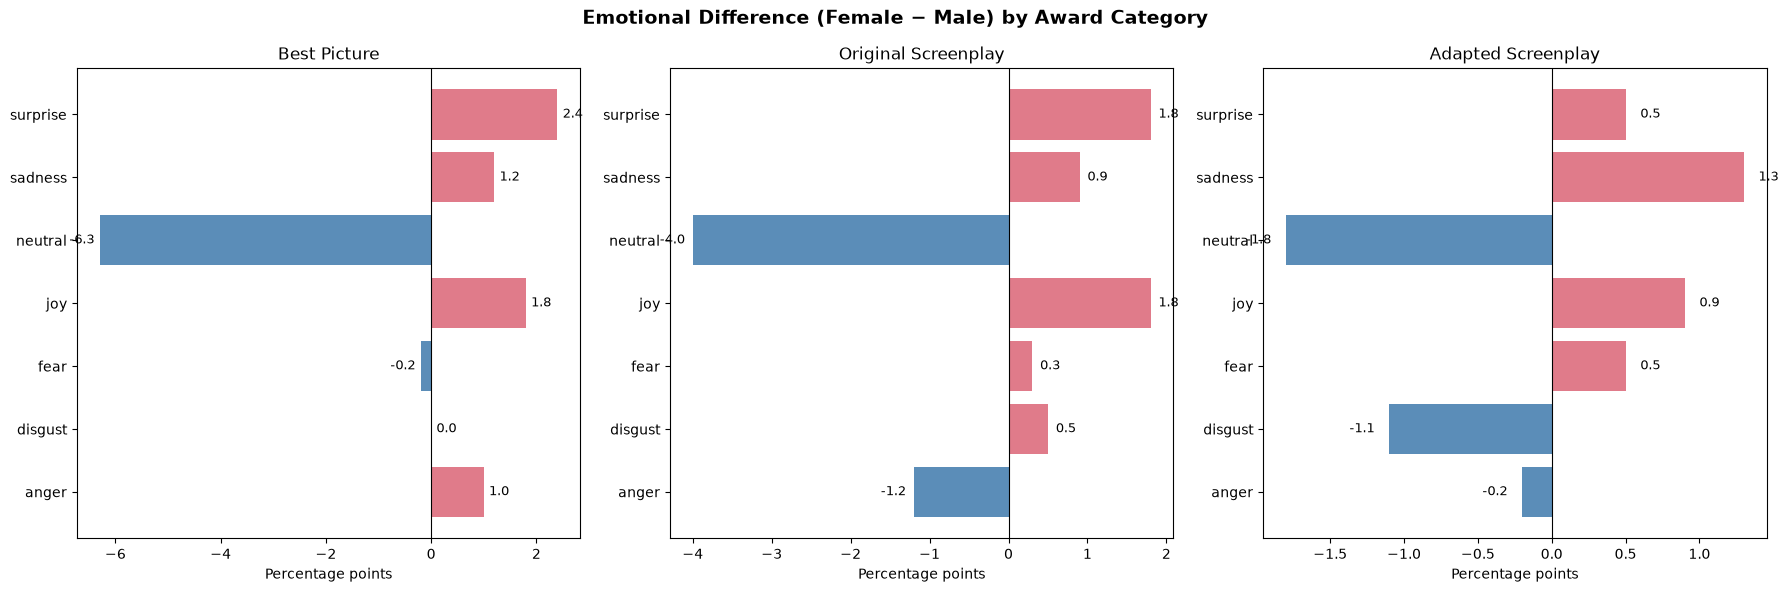

Gráfico guardado como hartmann_diferencia_award.png


In [26]:
# Gráfico 5 — Diferencia female - male por award
resumen_award2 = df_frases.groupby(['award', 'genero', 'emocion']).size().unstack(fill_value=0)
resumen_award2_pct = resumen_award2.div(resumen_award2.sum(axis=1), axis=0).round(3) * 100

awards = ['Best Picture', 'Original Screenplay', 'Adapted Screenplay']
emociones = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Emotional Difference (Female − Male) by Award Category", fontsize=14, fontweight='bold')

for i, award in enumerate(awards):
    female_vals = [resumen_award2_pct.loc[(award, 'female'), e] for e in emociones]
    male_vals = [resumen_award2_pct.loc[(award, 'male'), e] for e in emociones]
    diferencia = [f - m for f, m in zip(female_vals, male_vals)]
    colores = ['#E07B8A' if d > 0 else '#5B8DB8' for d in diferencia]
    bars = axes[i].barh(emociones, diferencia, color=colores)
    axes[i].axvline(x=0, color='black', linewidth=0.8)
    axes[i].set_title(award)
    axes[i].set_xlabel("Percentage points")
    for bar, val in zip(bars, diferencia):
        axes[i].text(val + 0.1 if val >= 0 else val - 0.1,
                    bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}', va='center',
                    ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig("hartmann_diferencia_award.png", dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico guardado como hartmann_diferencia_award.png")